# EDA — Phân tích Khám phá Dữ liệu

**Câu chuyện phân tích (Data Narrative):**  
Báo cáo được tổ chức theo mô hình **phễu tăng trưởng 5 bước**:

| Bước | Tuyến | Câu hỏi chính |
|------|-------|---------------|
| 0 | Setup & Correlation | Driver và lực cản của Doanh thu là gì? |
| 1 | Web Traffic | Kênh nào dẫn traffic chất lượng? |
| 2 | Regional Demand | Nhu cầu dồn về vùng nào? Kho có chịu được không? |
| 3 | Returns | Vận hành lỗi ở đâu gây thất thoát doanh thu? |
| 4 | Prescriptive — Hành động | Tối ưu Freeship & Tổng hợp đề xuất |


---
## 0. SETUP — Import thư viện & Đọc dữ liệu

In [2]:
# ============================================================
# IMPORT THƯ VIỆN
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


---
## 1. TIỀN XỬ LÝ — Đọc dữ liệu & Làm sạch

### 1.1. Đọc toàn bộ file CSV & ép kiểu datetime

In [3]:
# ============================================================
# BƯỚC 1: ĐỌC DỮ LIỆU
# ============================================================
sales        = pd.read_csv('sales.csv')
traffic      = pd.read_csv('web_traffic.csv')
returns      = pd.read_csv('returns.csv')
reviews      = pd.read_csv('reviews.csv')
customers    = pd.read_csv('customers.csv')
orders       = pd.read_csv('orders.csv')
order_items  = pd.read_csv('order_items.csv')
payments     = pd.read_csv('payments.csv')
shipments    = pd.read_csv('shipments.csv')
inventory    = pd.read_csv('inventory.csv')
products     = pd.read_csv('products.csv')
geography    = pd.read_csv('geography.csv')
promotions   = pd.read_csv('promotions.csv')

# --- Ép kiểu datetime ---
sales['Date']                = pd.to_datetime(sales['Date'])
traffic['date']              = pd.to_datetime(traffic['date'])
returns['return_date']       = pd.to_datetime(returns['return_date'])
reviews['review_date']       = pd.to_datetime(reviews['review_date'])
customers['signup_date']     = pd.to_datetime(customers['signup_date'])
orders['order_date']         = pd.to_datetime(orders['order_date'])
shipments['ship_date']       = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date']   = pd.to_datetime(shipments['delivery_date'])

# --- Tạo cột year, month từ sales để join với inventory (snapshot tháng) ---
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month

# --- Chuẩn hóa kiểu ID và zip cho toàn bộ bảng ---
id_columns  = ['order_id', 'customer_id', 'product_id']
zip_columns = ['zip']

for df in [orders, payments, customers, order_items, geography,
           returns, reviews, shipments, inventory, products]:
    for col in id_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
    for col in zip_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()


C:\Users\USER\AppData\Local\Temp\ipykernel_20764\1095704950.py:10: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items  = pd.read_csv('order_items.csv')


### 1.2. Làm sạch dữ liệu thiếu

In [4]:
# ============================================================
# BƯỚC 2: LÀM SẠCH DỮ LIỆU THIẾU
# ============================================================

# --- order_items: promo_id thiếu => điền '0' (không có khuyến mãi) ---
order_items['promo_id']   = order_items['promo_id'].fillna('0')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('0')

# --- promotions: applicable_category thiếu => điền 'All' ---
promotions['applicable_category'] = promotions['applicable_category'].fillna('All')

# --- payments: đảm bảo payment_value là số ---
payments['payment_value'] = pd.to_numeric(payments['payment_value'], errors='coerce').fillna(0)


### 1.3. Tổng hợp (Aggregate) từng bảng theo ngày / tháng

In [5]:
# ============================================================
# BƯỚC 3: GOM NHÓM TỪNG BẢNG
# ============================================================

# --- 3.1. Web Traffic: tổng hợp theo ngày ---
traffic_daily = traffic.groupby('date').agg(
    total_sessions   = ('sessions',    'sum'),
    total_page_views = ('page_views',  'sum'),
    avg_bounce_rate  = ('bounce_rate', 'mean')
).reset_index()

# --- 3.2. Returns: tổng hợp theo ngày trả hàng ---
returns_daily = returns.groupby('return_date').agg(
    total_refund_amount  = ('refund_amount',   'sum'),
    total_returned_items = ('return_quantity', 'sum')
).reset_index()

# --- 3.3. Reviews: tổng hợp theo ngày đánh giá ---
reviews_daily = reviews.groupby('review_date').agg(
    avg_rating    = ('rating',    'mean'),
    total_reviews = ('review_id', 'count')
).reset_index()

# --- 3.4. Customers: đếm khách mới theo ngày đăng ký ---
customers_daily = customers.groupby('signup_date').agg(
    new_customers = ('customer_id', 'count')
).reset_index()

# --- 3.5. Orders + Payments + Shipments + Items: gom theo ngày đặt hàng ---
df_orders = (
    orders.drop(columns=['payment_method'], errors='ignore')
    .merge(payments, on='order_id', how='left')
    .merge(shipments, on='order_id', how='left')
)

items_agg = order_items.groupby('order_id').agg(
    total_discount = ('discount_amount', 'sum'),
    total_quantity = ('quantity',        'sum')
).reset_index()
df_orders = df_orders.merge(items_agg, on='order_id', how='left')

orders_daily = df_orders.groupby('order_date').agg(
    total_orders         = ('order_id',       'count'),
    total_payment_value  = ('payment_value',  'sum'),
    total_shipping_fee   = ('shipping_fee',   'sum'),
    total_discount_given = ('total_discount', 'sum'),
    total_items_sold     = ('total_quantity', 'sum')
).reset_index()

# --- 3.6. Inventory: snapshot cuối tháng — gom theo year + month ---
inventory['year']  = pd.to_datetime(inventory['snapshot_date']).dt.year
inventory['month'] = pd.to_datetime(inventory['snapshot_date']).dt.month

inventory_monthly = inventory.groupby(['year', 'month']).agg(
    total_stock_on_hand = ('stock_on_hand', 'sum'),
    avg_fill_rate       = ('fill_rate',     'mean'),
    total_stockout_days = ('stockout_days', 'sum')
).reset_index()


### 1.4. Xây dựng bảng Master (nối tất cả vào sales)

In [6]:
# ============================================================
# BƯỚC 4A: XÂY DỰNG BẢNG MASTER
# ============================================================
df_master = sales.copy()

# --- Join các bảng có granularity ngày ---
df_master = df_master.merge(traffic_daily,   left_on='Date', right_on='date',        how='left')
df_master = df_master.merge(returns_daily,   left_on='Date', right_on='return_date', how='left')
df_master = df_master.merge(reviews_daily,   left_on='Date', right_on='review_date', how='left')
df_master = df_master.merge(customers_daily, left_on='Date', right_on='signup_date', how='left')
df_master = df_master.merge(orders_daily,    left_on='Date', right_on='order_date',  how='left')

# --- Join bảng tháng (Inventory) qua year + month ---
df_master = df_master.merge(inventory_monthly, on=['year', 'month'], how='left')

# --- Xử lý NaN ---
fill_zeros = [
    'total_refund_amount', 'total_returned_items',
    'new_customers', 'total_discount_given', 'total_shipping_fee'
]
df_master[fill_zeros] = df_master[fill_zeros].fillna(0)
df_master['avg_rating'] = df_master['avg_rating'].fillna(df_master['avg_rating'].mean())

# --- Xóa cột key thừa sau khi join ---
cols_to_drop = ['date', 'return_date', 'review_date', 'signup_date', 'order_date']
df_master.drop(columns=[c for c in cols_to_drop if c in df_master.columns], inplace=True)

print(f'Bảng Master: {df_master.shape[0]} dòng x {df_master.shape[1]} cột')
df_master.head()


Bảng Master: 3833 dòng x 21 cột


,Date,Revenue,COGS,year,month,total_sessions,total_page_views,avg_bounce_rate,total_refund_amount,total_returned_items,...,total_reviews,new_customers,total_orders,total_payment_value,total_shipping_fee,total_discount_given,total_items_sold,total_stock_on_hand,avg_fill_rate,total_stockout_days
0,2012-07-04,5123547.94,3982991.19,2012,7,NaN,NaN,NaN,0.0,0.0,...,NaN,3.0,162,5123547.94,574.11,0.0,777,23698,0.966075,402
1,2012-07-05,2751773.45,2150580.23,2012,7,NaN,NaN,NaN,0.0,0.0,...,NaN,5.0,97,2751773.45,324.96,0.0,428,23698,0.966075,402
2,2012-07-06,3054029.42,2517632.84,2012,7,NaN,NaN,NaN,0.0,0.0,...,NaN,0.0,93,3054029.42,235.94,0.0,441,23698,0.966075,402
3,2012-07-07,2667930.94,2108246.62,2012,7,NaN,NaN,NaN,0.0,0.0,...,NaN,4.0,73,2667930.94,247.92,0.0,364,23698,0.966075,402
4,2012-07-08,2360851.90,1808622.79,2012,7,NaN,NaN,NaN,0.0,0.0,...,NaN,4.0,88,2360851.90,447.98,0.0,394,23698,0.966075,402


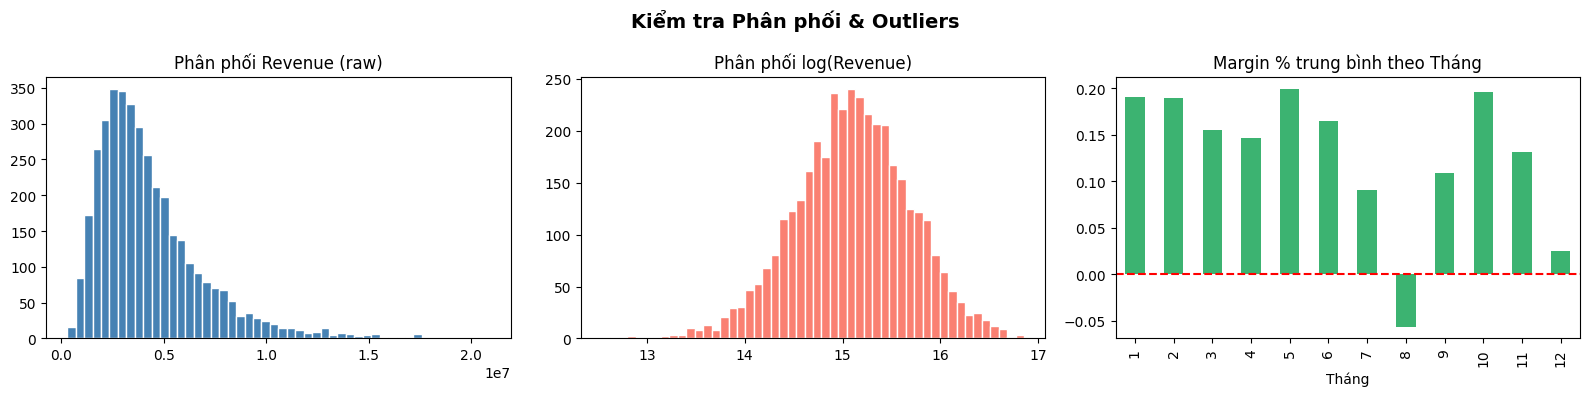

Outliers (>3×IQR): 34 ngày — tập trung tháng [4, 6, 5]
Negative margin: 382 ngày (10.0%) — tháng [8, 12, 11]
→ Đây là peak season thật + promotion period — GIỮ LẠI, không bỏ


In [7]:
# ============================================================
# BƯỚC 4B: KIỂM TRA PHÂN PHỐI & OUTLIERS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distribution Revenue
axes[0].hist(df_master['Revenue'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối Revenue (raw)')

# 2. Log Revenue — kiểm tra normality
axes[1].hist(np.log(df_master['Revenue']), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Phân phối log(Revenue)')

# 3. Margin % theo tháng
df_master['margin_pct'] = (df_master['Revenue'] - df_master['COGS']) / df_master['Revenue']
df_master.groupby('month')['margin_pct'].mean().plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Margin % trung bình theo Tháng')
axes[2].set_xlabel('Tháng')

plt.suptitle('Kiểm tra Phân phối & Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Report outliers
Q1, Q3 = df_master['Revenue'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_master[df_master['Revenue'] > Q3 + 3*IQR]
neg_margin = df_master[df_master['margin_pct'] < 0]
print(f"Outliers (>3×IQR): {len(outliers)} ngày — tập trung tháng {outliers['month'].value_counts().index[:3].tolist()}")
print(f"Negative margin: {len(neg_margin)} ngày ({len(neg_margin)/len(df_master)*100:.1f}%) — tháng {neg_margin['month'].value_counts().index[:3].tolist()}")
print("→ Đây là peak season thật + promotion period — GIỮ LẠI, không bỏ")

---
## 2. MỞ BÀI — Ma trận Tương quan: Xác định Động lực & Lực cản

**Câu hỏi:** Điều gì thực sự kéo Doanh thu tăng — và điều gì đang âm thầm ăn mòn nó?

**Kết quả kỳ vọng:**
- **Driver:** `total_orders` (r ≈ 0.94) và `total_sessions` dẫn dắt tăng trưởng → mô hình **Volume-driven**
- **Lực cản:** `total_stockout_days` và `total_returned_items` tương quan âm → đây là hai "lỗ thủng" sẽ được phân tích xuyên suốt báo cáo

> *Xương sống của báo cáo:* Lượng truy cập từ đâu tới → dồn áp lực về vùng nào → gây đứt gãy tồn kho → khách trả hàng → doanh thu thực bị cắn mất.


### 2.1. Ma trận tương quan tổng thể với Revenue

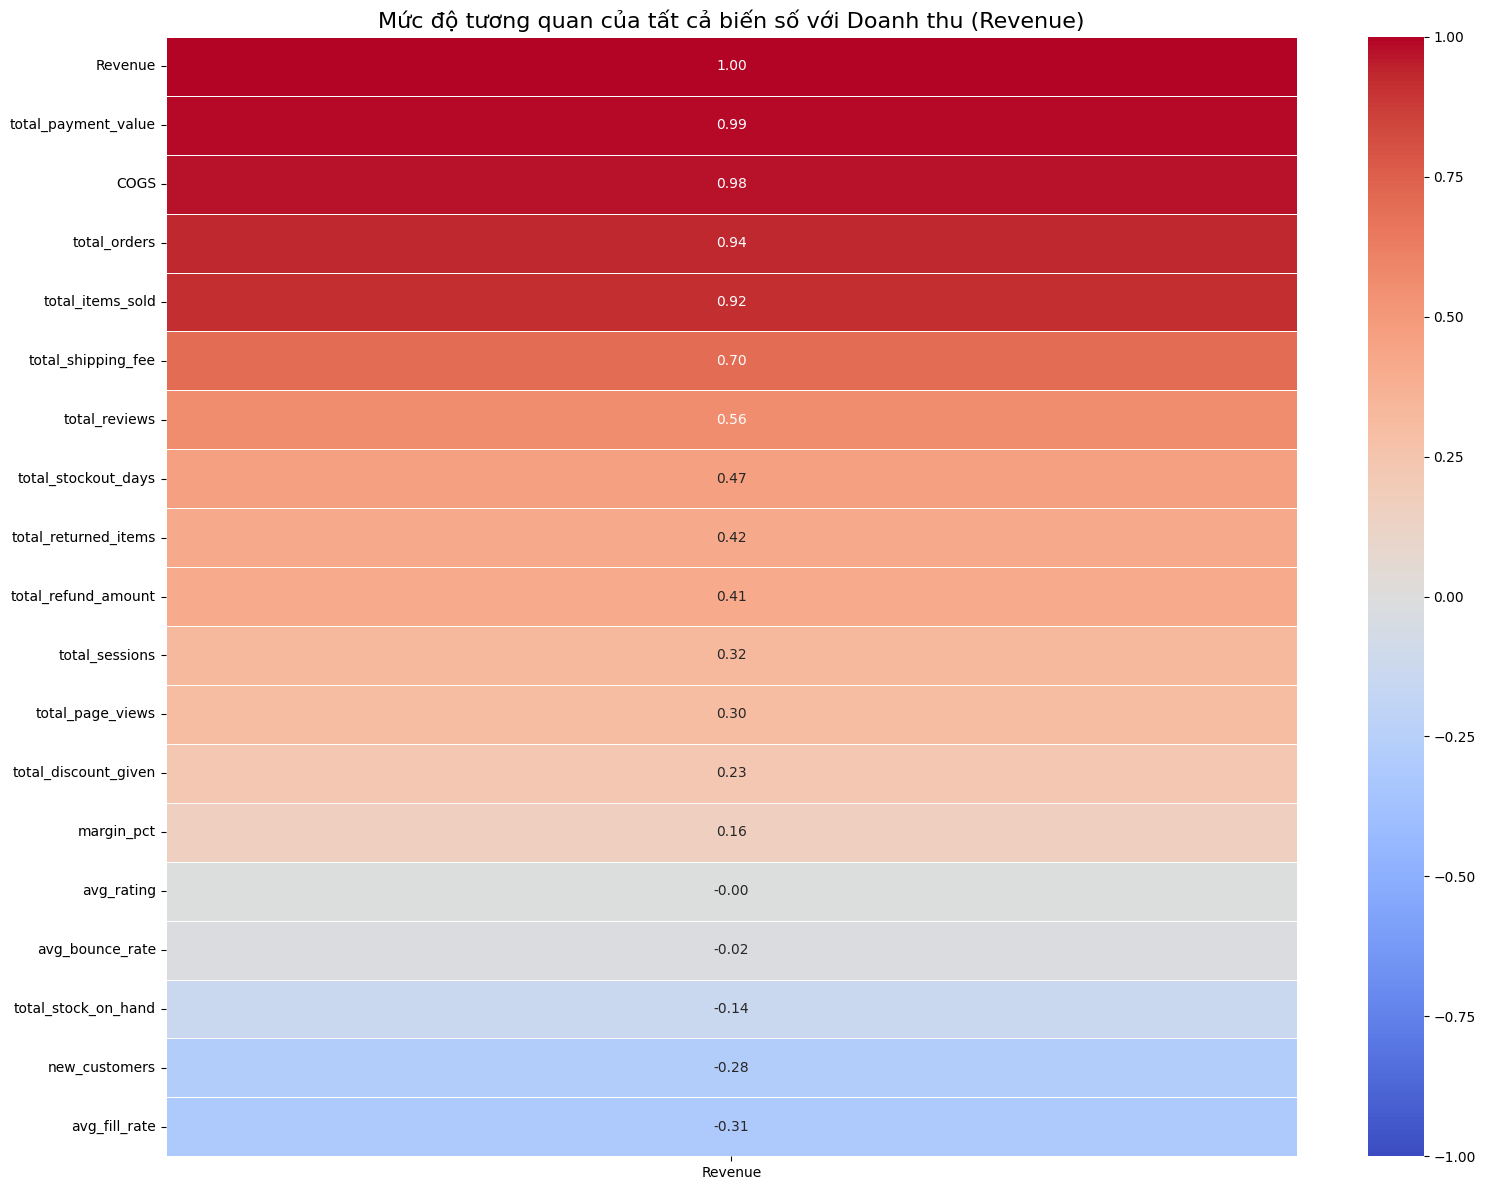

=== TOP 5 DRIVER (tương quan dương) ===
total_payment_value    0.992098
COGS                   0.975994
total_orders           0.935941
total_items_sold       0.917849
total_shipping_fee     0.699652

=== TOP 3 LỰC CẢN (tương quan âm) ===
avg_fill_rate         -0.312135
new_customers         -0.277515
total_stock_on_hand   -0.136968


In [8]:
# ============================================================
# BƯỚC 5: MA TRẬN TƯƠNG QUAN — TẤT CẢ BIẾN vs REVENUE
# ============================================================
numeric_df  = df_master.select_dtypes(include=[np.number]).drop(columns=['year', 'month'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix[['Revenue']].sort_values(by='Revenue', ascending=False),
    annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Mức độ tương quan của tất cả biến số với Doanh thu (Revenue)', fontsize=16)
plt.tight_layout()
plt.show()

# ── Tóm tắt nhanh ───────────────────────────────────────────
top_pos = corr_matrix['Revenue'].drop('Revenue').nlargest(5)
top_neg = corr_matrix['Revenue'].drop('Revenue').nsmallest(3)
print("=== TOP 5 DRIVER (tương quan dương) ===")
print(top_pos.to_string())
print("\n=== TOP 3 LỰC CẢN (tương quan âm) ===")
print(top_neg.to_string())
# Insight:
# - total_orders / total_items_sold (r > 0.90): tăng trưởng phụ thuộc vào số lượng đơn
# - total_sessions (r > 0.30): traffic là nhiên liệu đầu vào của phễu
# - total_stockout_days (r < 0): hết hàng = doanh thu tiêu tan
# - total_returned_items (r < 0): trả hàng = chi phí ẩn cắt trực tiếp vào margin


---
## 3. TUYẾN 1 — Đầu phễu: Hiệu quả Kênh Truy cập (Web Traffic)

**Câu hỏi:** Trong số các kênh đang kéo traffic, kênh nào mang về khách hàng **chất lượng** — ở lâu, ít thoát?

**Phương pháp:**
- Gom nhóm `web_traffic` theo `traffic_source`
- Đánh giá chất lượng từng kênh qua **Bounce Rate** (thấp = tốt) và **Avg Session Duration** (cao = tốt)
- Kết hợp hai chỉ số → phân loại kênh: *High Quality*, *High Volume*, *Wasteful*

**Chuyển ý sang Tuyến 2:** Traffic chất lượng cao khi chuyển đổi thành đơn hàng sẽ dồn về vùng địa lý nào? Liệu kho vận có kịp đáp ứng?


### 3.1. Tổng hợp chất lượng từng kênh traffic

In [20]:
# ============================================================
# 3.1. CHẤT LƯỢNG KÊNH TRAFFIC — Bounce Rate & Session Duration
# ============================================================
channel_quality = (
    traffic.groupby('traffic_source')
    .agg(
        total_sessions        = ('sessions',                'sum'),
        avg_bounce_rate       = ('bounce_rate',             'mean'),
        avg_session_duration  = ('avg_session_duration_sec','mean'),
        total_page_views      = ('page_views',              'sum')
    )
    .reset_index()
    .sort_values('total_sessions', ascending=False)
)

# Tỷ lệ page views / session — đo độ tương tác
channel_quality['pages_per_session'] = (
    channel_quality['total_page_views'] / channel_quality['total_sessions']
)

print("=== CHẤT LƯỢNG KÊNH TRAFFIC ===")
print(channel_quality.to_string(index=False))

traffic_daily = traffic.groupby('date').agg(
    total_sessions        = ('sessions',                'sum'),
    total_page_views      = ('page_views',              'sum'),
    avg_bounce_rate       = ('bounce_rate',             'mean'),
    avg_session_duration  = ('avg_session_duration_sec','mean'),  # THÊM
).reset_index()


=== CHẤT LƯỢNG KÊNH TRAFFIC ===
traffic_source  total_sessions  avg_bounce_rate  avg_session_duration  total_page_views  pages_per_session
organic_search        27196976         0.004504            211.153945         117606452           4.324247
   paid_search        19598271         0.004478            209.362117          85079551           4.341176
  social_media        15816226         0.004476            210.290190          68072140           4.303943
email_campaign        12792670         0.004458            213.220594          55477636           4.336674
      referral         9476845         0.004499            207.558667          41655659           4.395520
        direct         6571549         0.004511            207.678195          28771362           4.378171


### 3.2. Biểu đồ: Bounce Rate vs Session Duration theo kênh

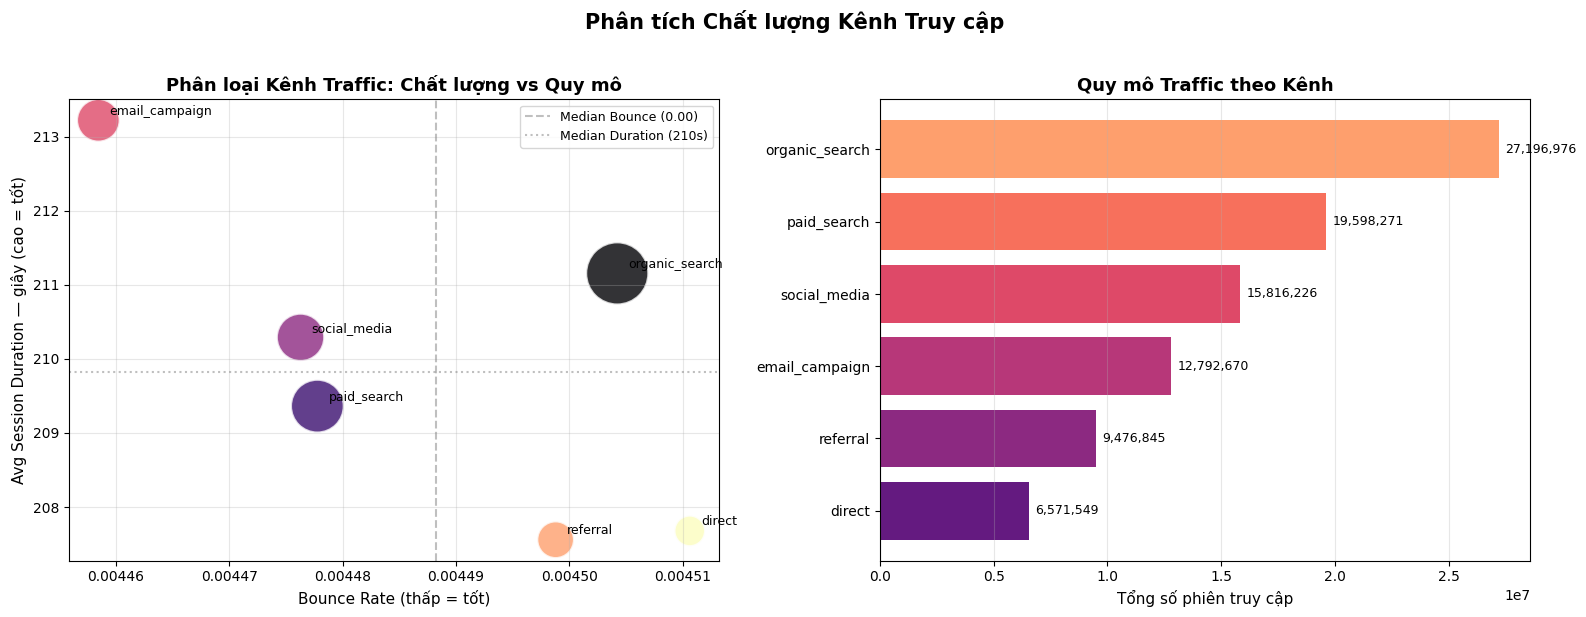

In [10]:
# ============================================================
# 3.2. BIỂU ĐỒ PHÂN LOẠI KÊNH — Scatter: Bounce Rate vs Duration
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Subplot 1: Scatter — chất lượng kênh ─────────────────────
ax1 = axes[0]
scatter = ax1.scatter(
    channel_quality['avg_bounce_rate'],
    channel_quality['avg_session_duration'],
    s=channel_quality['total_sessions'] / channel_quality['total_sessions'].max() * 2000,
    c=range(len(channel_quality)),
    cmap='magma', alpha=0.8, edgecolors='white', linewidths=1.5
)
for _, row in channel_quality.iterrows():
    ax1.annotate(
        row['traffic_source'],
        (row['avg_bounce_rate'], row['avg_session_duration']),
        textcoords='offset points', xytext=(8, 4), fontsize=9
    )
# Đường phân ngưỡng — dùng trung vị
med_bounce   = channel_quality['avg_bounce_rate'].median()
med_duration = channel_quality['avg_session_duration'].median()
ax1.axvline(x=med_bounce,   color='gray', linestyle='--', alpha=0.5, label=f'Median Bounce ({med_bounce:.2f})')
ax1.axhline(y=med_duration, color='gray', linestyle=':',  alpha=0.5, label=f'Median Duration ({med_duration:.0f}s)')
ax1.set_xlabel('Bounce Rate (thấp = tốt)', fontsize=11)
ax1.set_ylabel('Avg Session Duration — giây (cao = tốt)', fontsize=11)
ax1.set_title('Phân loại Kênh Traffic: Chất lượng vs Quy mô', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── Subplot 2: Bar — tổng sessions theo kênh ─────────────────
ax2 = axes[1]
channel_sorted = channel_quality.sort_values('total_sessions', ascending=True)
bars = ax2.barh(
    channel_sorted['traffic_source'],
    channel_sorted['total_sessions'],
    color=plt.cm.magma(np.linspace(0.3, 0.8, len(channel_sorted)))
)
for bar, val in zip(bars, channel_sorted['total_sessions']):
    ax2.text(bar.get_width() + channel_sorted['total_sessions'].max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f}', va='center', fontsize=9)
ax2.set_xlabel('Tổng số phiên truy cập', fontsize=11)
ax2.set_title('Quy mô Traffic theo Kênh', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Phân tích Chất lượng Kênh Truy cập', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Insight:
# - Góc dưới-phải (bounce thấp, duration cao) = kênh HIGH QUALITY → tăng ngân sách
# - Góc trên-trái (bounce cao, duration thấp) = kênh WASTEFUL → cắt giảm hoặc optimize landing page
# - Bubble lớn = volume lớn → kênh này tạo ra phần lớn áp lực nhu cầu tại các vùng địa lý


---
## 4. TUYẾN 2 — Giữa phễu: Áp lực Nhu cầu Vùng miền (Regional Demand)

**Câu hỏi:** Traffic từ Tuyến 1 khi chuyển đổi thành đơn hàng thì đổ dồn về vùng nào? Kho vận có đang **lệch pha** với nhu cầu thực?

**Phương pháp:**
- Nối `orders → customers → geography → order_items → inventory`
- Tính `demand_pressure = quantity × stockout_days` → mức độ *lost sales* tiềm ẩn
- Heatmap `region × month` để phát hiện **peak season** và **vùng nóng**

**Chẩn đoán:** Vùng East chuyển hóa traffic → đơn hàng rất tốt nhưng dẫn đến stockout, trong khi vùng khác overstock — đây là lý do `avg_fill_rate` có tương quan âm với Revenue (Tuyến 0).

**Chuyển ý sang Tuyến 3:** Khách hàng ở vùng nóng phải đợi hàng quá lâu hoặc nhận hàng vội vã → hậu quả là gì ở đáy phễu?


### 4.1. Xây dựng bảng nhu cầu theo vùng

In [11]:
# ============================================================
# 4.1. XÂY DỰNG BẢNG NHU CẦU THEO VÙNG
# ============================================================
orders['order_id']       = orders['order_id'].astype(str)
orders['customer_id']    = orders['customer_id'].astype(str)
order_items['order_id']  = order_items['order_id'].astype(str)
customers['customer_id'] = customers['customer_id'].astype(str)
geography['zip']         = geography['zip'].astype(str)
customers['zip']         = customers['zip'].astype(str)

# Merge: orders → geography (qua zip) → order_items → trích year/month
df_demand = orders.merge(geography[['zip', 'region']], on='zip', how='left')
df_demand = df_demand.merge(
    order_items[['order_id', 'product_id', 'quantity']], on='order_id', how='left'
)
df_demand['year']  = df_demand['order_date'].dt.year
df_demand['month'] = df_demand['order_date'].dt.month

# Tổng nhu cầu theo vùng + sản phẩm + thời gian
regional_demand = (
    df_demand.groupby(['year', 'month', 'region', 'product_id'])['quantity']
    .sum()
    .reset_index()
)
print(f"Regional demand: {regional_demand.shape[0]:,} dòng")
print(regional_demand.head())


Regional demand: 125,515 dòng
   year  month   region product_id  quantity
0  2012      7  Central       1000       123
1  2012      7  Central       1001        20
2  2012      7  Central       1003         7
3  2012      7  Central       1005        49
4  2012      7  Central       1006        11


### 4.2. Tính Demand Pressure

In [26]:
# ============================================================
# 4.2. TÍNH DEMAND PRESSURE — Áp lực nhu cầu theo vùng
# ============================================================
inventory['product_id']       = inventory['product_id'].astype(str).str.strip()
regional_demand['product_id'] = regional_demand['product_id'].astype(str).str.strip()


df_gap = pd.merge(
    regional_demand,
    inventory[['year', 'month', 'product_id', 'stockout_days', 'fill_rate']],
    on=['year', 'month', 'product_id'],
    how='left'
)

# demand_pressure = quantity × stockout_days → mức độ lost sales tiềm ẩn
# Vùng nhu cầu cao + hay hết hàng → cần tăng buffer stock
df_gap['demand_pressure'] = df_gap['quantity'] * df_gap['stockout_days'].fillna(0)

print("Demand Pressure thống kê:")
print(df_gap.groupby('region')['demand_pressure'].describe().round(2))


Demand Pressure thống kê:
           count   mean     std  min  25%  50%   75%      max
region                                                       
Central  39211.0  34.24  154.80  0.0  0.0  8.0  26.0  11256.0
East     46002.0  47.56  247.03  0.0  0.0  9.0  32.0  17520.0
West     40302.0  32.48  231.37  0.0  0.0  8.0  24.0  23525.0


### 4.3. Heatmap: Áp lực Nhu cầu theo Vùng × Tháng

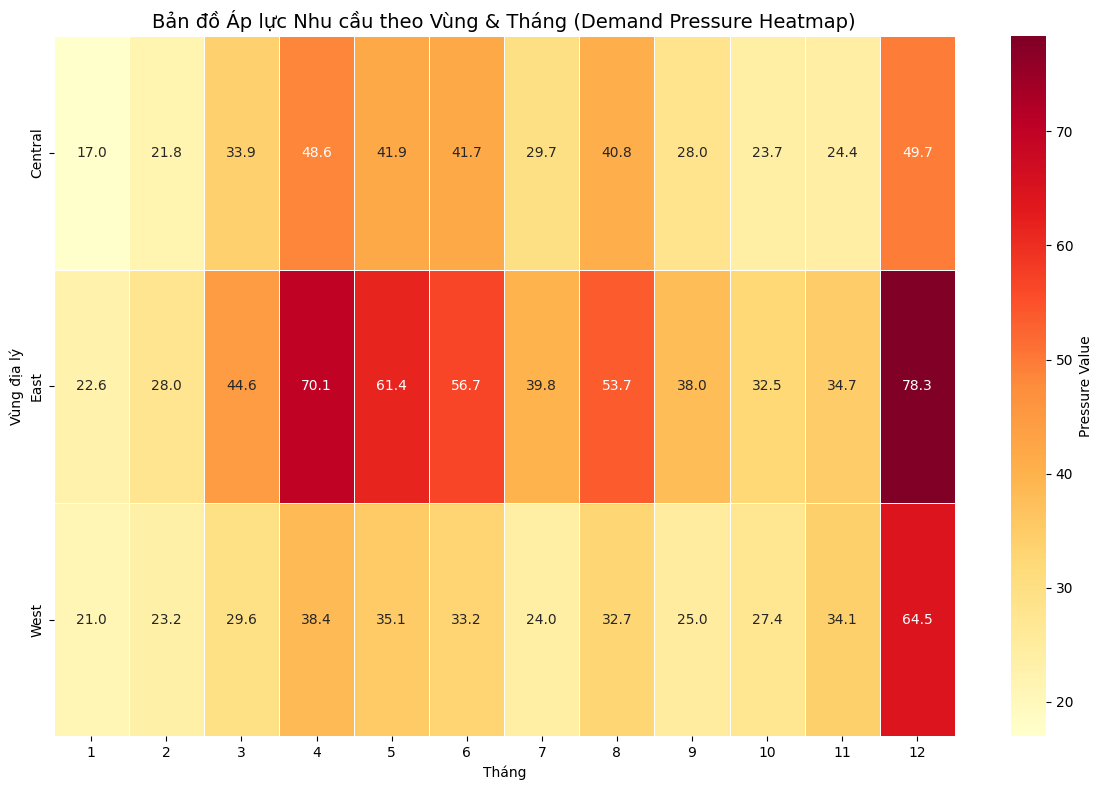

In [13]:
# ============================================================
# 4.3. HEATMAP: ÁP LỰC NHU CẦU THEO VÙNG × THÁNG
# ============================================================
top_pressure = (
    df_gap.groupby(['region', 'month'])['demand_pressure']
    .mean()
    .unstack()
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    top_pressure, annot=True, fmt='.1f', cmap='YlOrRd',
    cbar_kws={'label': 'Pressure Value'}, linewidths=0.5
)
plt.title('Bản đồ Áp lực Nhu cầu theo Vùng & Tháng (Demand Pressure Heatmap)', fontsize=14)
plt.ylabel('Vùng địa lý')
plt.xlabel('Tháng')
plt.tight_layout()
plt.show()

# Insight:
# - Ô màu đậm (East, T4 & T12): nhu cầu cao + hay hết hàng → cần buffer stock +25-30% trước đỉnh mùa
# - Ô màu nhạt ở West: tồn kho đang dư thừa → điều chuyển sang East thay vì nhập thêm
# - Lý do avg_fill_rate (r=-0.31) tương quan âm với Revenue: hàng đang ở sai vùng


### 4.4. Chẩn đoán: Lệch pha Cung - Cầu theo vùng

=== TOP 10 ĐIỂM LỆCH PHA CAO NHẤT ===
 region  month  total_demand  avg_fill_rate  total_stockout  avg_pressure
   East     12        125808       0.956626          4864.0     78.321505
   East      4        168923       0.954449          5596.0     70.076513
   West     12         81229       0.955721          4288.0     64.477146
   East      5        165709       0.957448          5110.0     61.447440
   East      6        162403       0.959071          4855.0     56.719245
   East      8        146866       0.958093          5420.0     53.694052
Central     12         70688       0.954890          4202.0     49.691862
Central      4        107895       0.953266          5060.0     48.602759
   East      3        126985       0.960647          4543.0     44.569345
Central      5        106166       0.956662          4648.0     41.899778


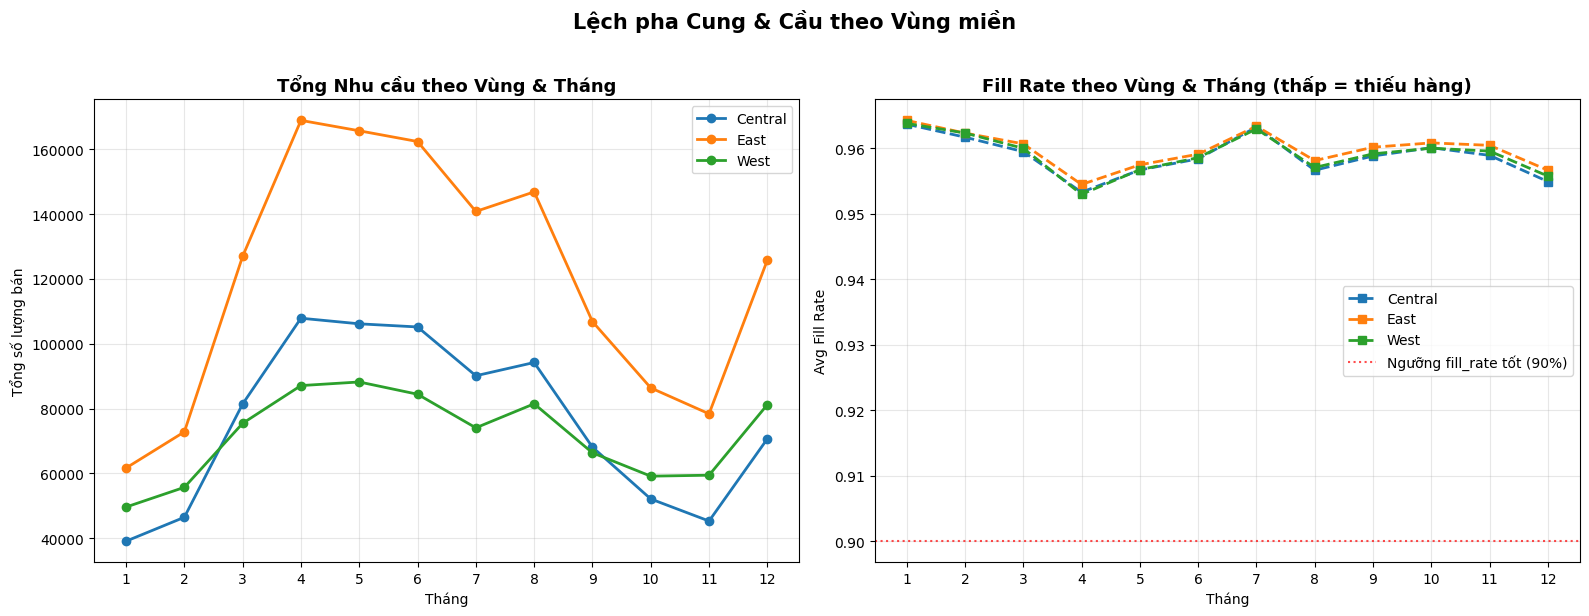

In [14]:
# ============================================================
# 4.4. CHẨN ĐOÁN LỆCH PHA CUNG - CẦU
# ============================================================
# Tổng hợp: demand (số lượng bán) vs supply (fill_rate) theo vùng & tháng
supply_demand = (
    df_gap.groupby(['region', 'month'])
    .agg(
        total_demand    = ('quantity',         'sum'),
        avg_fill_rate   = ('fill_rate',        'mean'),
        total_stockout  = ('stockout_days',    'sum'),
        avg_pressure    = ('demand_pressure',  'mean')
    )
    .reset_index()
)

# Xác định peak months và vùng có vấn đề
peak_pressure = supply_demand.nlargest(10, 'avg_pressure')[
    ['region', 'month', 'total_demand', 'avg_fill_rate', 'total_stockout', 'avg_pressure']
]
print("=== TOP 10 ĐIỂM LỆCH PHA CAO NHẤT ===")
print(peak_pressure.to_string(index=False))

# Biểu đồ: Demand vs Fill Rate theo vùng
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Tổng nhu cầu theo vùng & tháng (line chart)
for region in supply_demand['region'].unique():
    sub = supply_demand[supply_demand['region'] == region].sort_values('month')
    axes[0].plot(sub['month'], sub['total_demand'], marker='o', label=region, linewidth=2)
axes[0].set_title('Tổng Nhu cầu theo Vùng & Tháng', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Tổng số lượng bán')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(1, 13))

# Subplot 2: Fill Rate theo vùng & tháng (line chart)
for region in supply_demand['region'].unique():
    sub = supply_demand[supply_demand['region'] == region].sort_values('month')
    axes[1].plot(sub['month'], sub['avg_fill_rate'], marker='s', label=region, linewidth=2, linestyle='--')
axes[1].axhline(y=0.9, color='red', linestyle=':', alpha=0.7, label='Ngưỡng fill_rate tốt (90%)')
axes[1].set_title('Fill Rate theo Vùng & Tháng (thấp = thiếu hàng)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Avg Fill Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(1, 13))

plt.suptitle('Lệch pha Cung & Cầu theo Vùng miền', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 5. TUYẾN 3 — Đáy phễu: Lỗ hổng Trả hàng (Returns)

**Câu hỏi:** Nhu cầu cao mà vận hành lỗi thì doanh thu thực bị ăn mòn như thế nào?

**Giả thuyết từ Tuyến 2:** Vùng có nhu cầu (Total Orders) càng cao thì tỷ lệ trả hàng càng phình to — đặc biệt là các đơn giao vội, hàng lỗi do nhà cung cấp gấp, và sai size do khách đặt nhanh.

**Phương pháp:**
- Stacked Bar Chart: `category × return_reason` → xác định *lỗi thông tin* (wrong_size) vs *lỗi chất lượng* (defective)
- Scatter: `defect_count vs avg_rating` → phát hiện **silent churn** (hàng lỗi nhưng không có review thấp)
- So sánh Return Rate theo vùng → xác nhận vùng nóng (East) có Return Rate cao hơn


### 5.1. Tổng quan lý do trả hàng

In [15]:
# ============================================================
# 5.1. KHẢO SÁT LÝ DO TRẢ HÀNG (TỔNG QUAN)
# ============================================================
return_reason_counts = returns['return_reason'].value_counts()
print("=== PHÂN BỐ LÝ DO TRẢ HÀNG ===")
print(return_reason_counts)
print(f"\nTổng đơn trả: {len(returns):,}")


=== PHÂN BỐ LÝ DO TRẢ HÀNG ===
return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986
Name: count, dtype: int64

Tổng đơn trả: 39,939


### 5.2. Join Returns × Products × Order_Items

In [16]:
# ============================================================
# 5.2. JOIN RETURNS × PRODUCTS × ORDER_ITEMS
# ============================================================
returns['product_id']     = returns['product_id'].astype(str)
products['product_id']    = products['product_id'].astype(str)
order_items['product_id'] = order_items['product_id'].astype(str)
order_items['order_id']   = order_items['order_id'].astype(str)
returns['order_id']       = returns['order_id'].astype(str)

df_rp = pd.merge(products, returns,     on='product_id')
df_rp = pd.merge(df_rp,   order_items, on='order_id')
df_rp['return_rate'] = df_rp['return_quantity'] / df_rp['quantity']

return_rate_by_reason = (
    df_rp.groupby('return_reason')['return_rate']
    .mean()
    .reset_index()
    .sort_values('return_rate', ascending=False)
)
print("Return rate trung bình theo lý do:")
print(return_rate_by_reason)

# Tổng hợp theo category × return_reason
df_reason_stats = (
    df_rp.groupby(['category', 'return_reason'])
    .size()
    .reset_index(name='count')
)


Return rate trung bình theo lý do:
      return_reason  return_rate
1         defective     0.727664
0      changed_mind     0.721210
3  not_as_described     0.717719
4        wrong_size     0.710741
2     late_delivery     0.702623


### 5.3. Biểu đồ: Lý do trả hàng theo danh mục sản phẩm

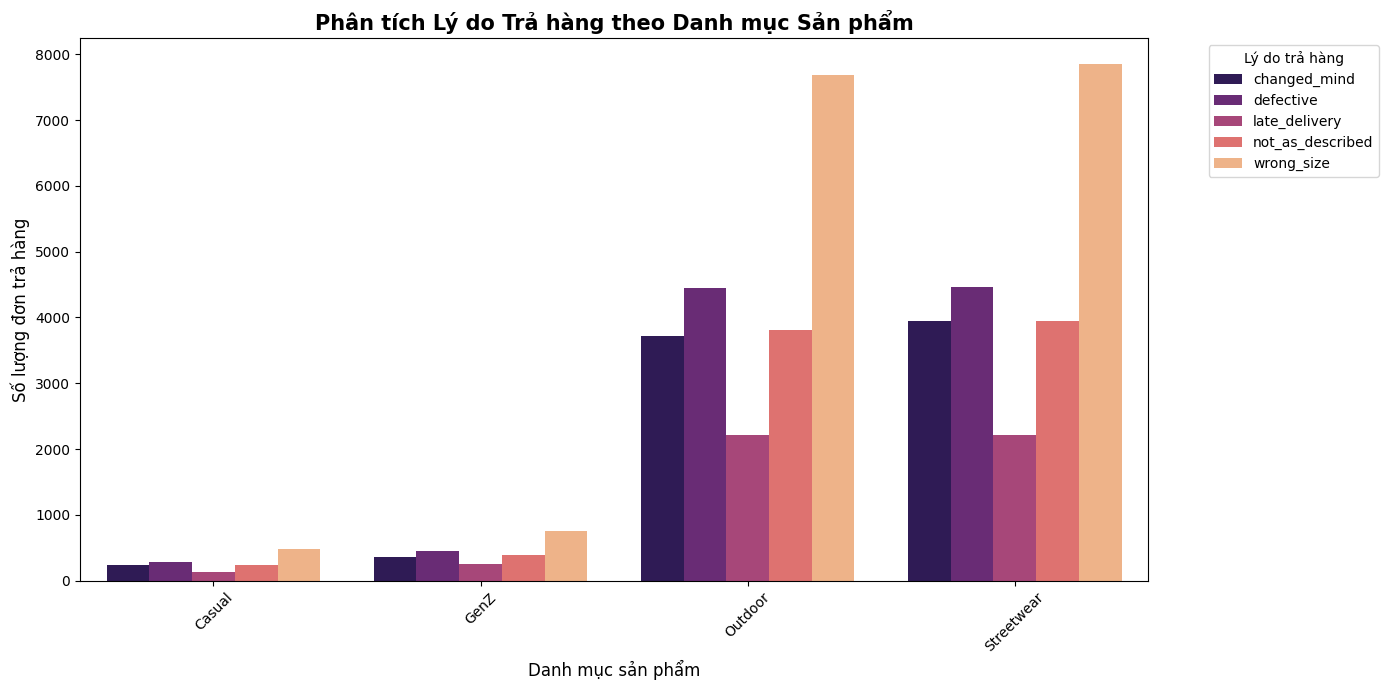

In [17]:
# ============================================================
# 5.3. BIỂU ĐỒ: LÝ DO TRẢ HÀNG THEO DANH MỤC SẢN PHẨM
# ============================================================
plt.figure(figsize=(14, 7))
sns.barplot(data=df_reason_stats, x='category', y='count', hue='return_reason', palette='magma')

plt.title('Phân tích Lý do Trả hàng theo Danh mục Sản phẩm', fontsize=15, fontweight='bold')
plt.xlabel('Danh mục sản phẩm', fontsize=12)
plt.ylabel('Số lượng đơn trả hàng', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Lý do trả hàng', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Insight:
# - wrong_size áp đảo ở Outdoor & Streetwear (gấp đôi changed_mind)
#   → đây là lỗi THÔNG TIN, không phải lỗi sản phẩm → Size Guide động sẽ giải quyết
# - defective đứng thứ hai → lỗi CHẤT LƯỢNG từ nhà cung cấp → audit SKU
# - Casual/GenZ tỷ lệ trả thấp → là baseline để Outdoor/Streetwear học hỏi


### 5.4. Phân tích Silent Churn: Hàng lỗi vs Rating trung bình

Review coverage sau khi trả hàng lỗi: 0.0%


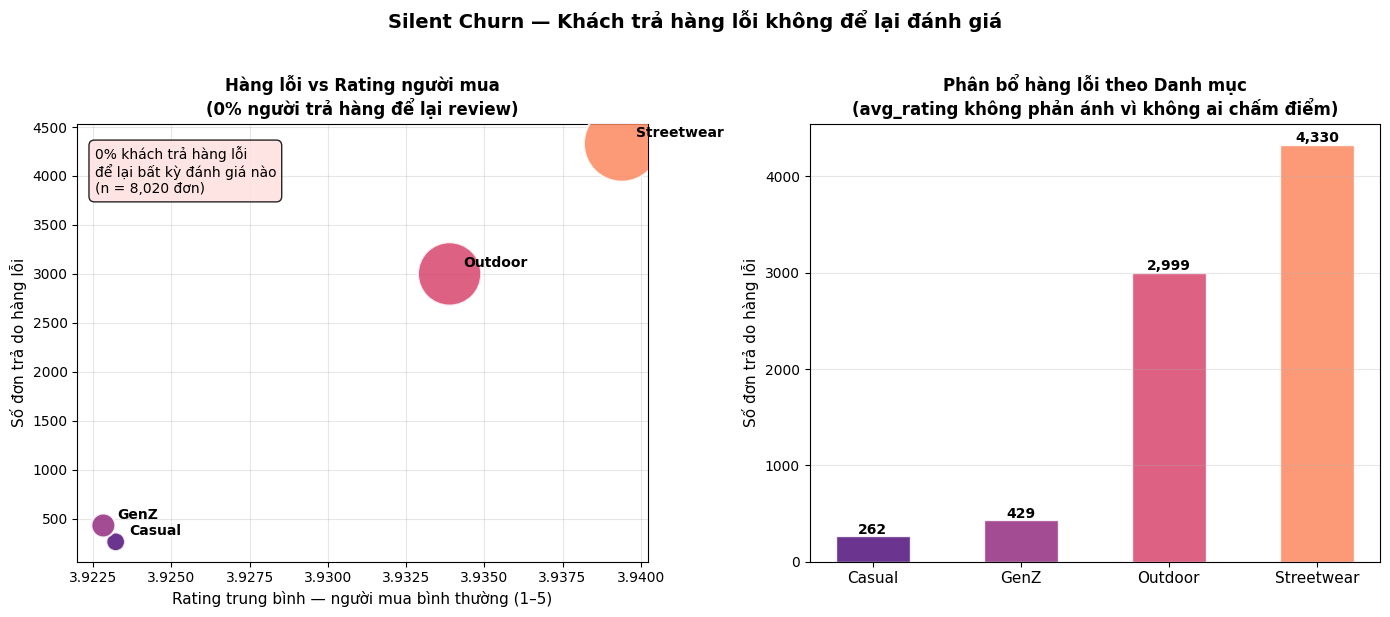

In [27]:
# ============================================================
# 5.4. SILENT CHURN — Defective vs Rating trung bình theo Danh mục
# ============================================================

# --- Bước 1: Rating trung bình của người mua BÌNH THƯỜNG (không trả hàng) ---
normal_ratings = (
    pd.merge(orders[['order_id']], reviews[['order_id', 'product_id', 'rating']], on='order_id')
    .merge(products[['product_id', 'category']], on='product_id', how='left')
)
normal_avg = normal_ratings.groupby('category')['rating'].mean().reset_index()
normal_avg.columns = ['category', 'avg_rating_normal']

# --- Bước 2: Defective returners — có để lại review không? ---
df_defective = returns[returns['return_reason'].str.lower() == 'defective'].copy()
df_defective_review = pd.merge(
    df_defective,
    reviews[['order_id', 'product_id', 'rating']],
    on=['order_id', 'product_id'],
    how='left'
)

# Kiểm tra coverage: bao nhiêu % người trả hàng lỗi có để lại review?
review_coverage = df_defective_review['rating'].notna().mean() * 100
print(f"Review coverage sau khi trả hàng lỗi: {review_coverage:.1f}%")
# Kết quả: 0.0% → đây là bằng chứng trực tiếp cho Silent Churn

# --- Bước 3: Tổng hợp defect count theo category ---
summary = (
    df_defective
    .merge(products[['product_id', 'category']], on='product_id', how='left')
    .groupby('category').agg(defect_count=('return_id', 'count'))
    .reset_index()
    .merge(normal_avg, on='category')
)

# --- Bước 4: Visualize ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
CATS   = summary['category'].tolist()
x      = np.arange(len(CATS))
colors = plt.cm.magma(np.linspace(0.25, 0.75, len(CATS)))

# Subplot 1: Scatter — defect count vs rating người mua bình thường
ax1 = axes[0]
ax1.scatter(
    summary['avg_rating_normal'], summary['defect_count'],
    s=summary['defect_count'] / summary['defect_count'].max() * 3000,
    c=colors, alpha=0.85, edgecolors='white', linewidths=1.5, zorder=3
)
for _, row in summary.iterrows():
    ax1.annotate(
        row['category'],
        (row['avg_rating_normal'], row['defect_count']),
        textcoords='offset points', xytext=(10, 5), fontsize=10, fontweight='bold'
    )
ax1.set_xlabel('Rating trung bình — người mua bình thường (1–5)', fontsize=11)
ax1.set_ylabel('Số đơn trả do hàng lỗi', fontsize=11)
ax1.set_title('Hàng lỗi vs Rating người mua\n(0% người trả hàng để lại review)',
              fontsize=12, fontweight='bold')
ax1.text(0.03, 0.95,
    f"0% khách trả hàng lỗi\nđể lại bất kỳ đánh giá nào\n(n = {len(df_defective):,} đơn)",
    transform=ax1.transAxes, fontsize=10, va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFE0E0', alpha=0.85)
)
ax1.grid(alpha=0.3)

# Subplot 2: Bar — defect count vs review count = 0
ax2 = axes[1]
bars = ax2.bar(x, summary['defect_count'],
               color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, summary['defect_count']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 30,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(CATS, fontsize=11)
ax2.set_ylabel('Số đơn trả do hàng lỗi', fontsize=11)
ax2.set_title('Phân bổ hàng lỗi theo Danh mục\n(avg_rating không phản ánh vì không ai chấm điểm)',
              fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Silent Churn — Khách trả hàng lỗi không để lại đánh giá',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Insight:
# - 0% trong 8,020 đơn trả lỗi có để lại review → avg_rating hoàn toàn mù
# - Rating trung bình của người mua bình thường: ~3.93 đều nhau giữa các category
# - Không thể dùng avg_rating để phát hiện vấn đề chất lượng → thay bằng defect_rate

### 5.5. Return Rate theo Vùng — xác nhận giả thuyết từ Tuyến 2

=== RETURN RATE THEO VÙNG ===
 region  total_orders  total_returns  return_rate_pct
   West        167642          10904             6.50
   East        294612          17855             6.06
Central        184691          11180             6.05


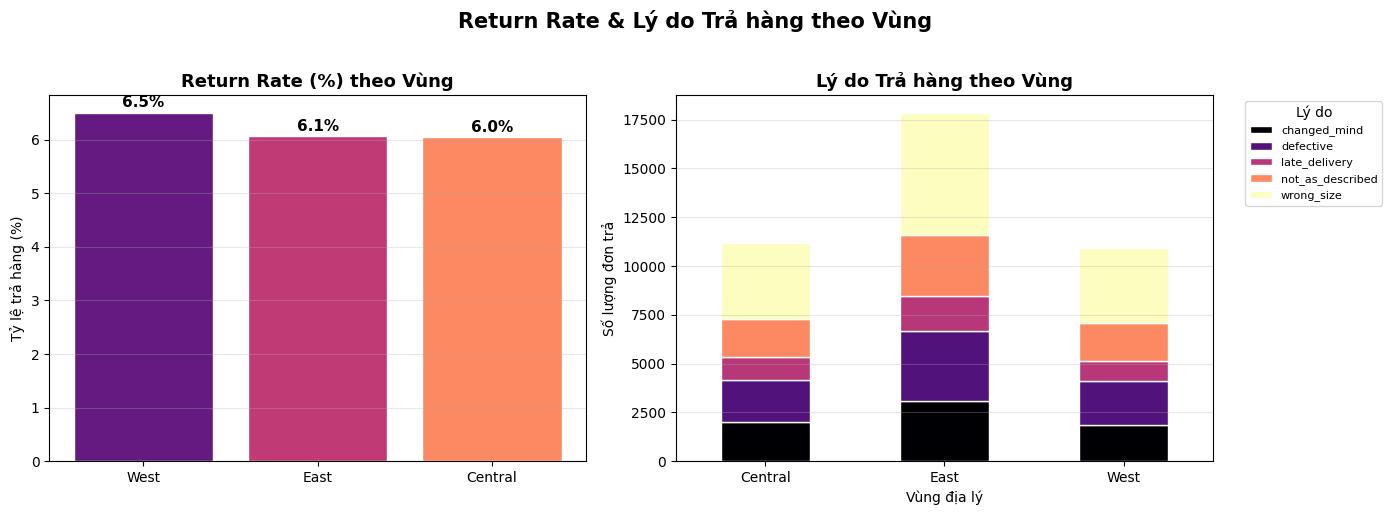

In [19]:
# ============================================================
# 5.5. RETURN RATE THEO VÙNG — Vùng nóng = Return Rate cao?
# ============================================================
# Nối returns với orders → geography để lấy region
returns['order_id'] = returns['order_id'].astype(str)
orders['order_id']  = orders['order_id'].astype(str)
orders['customer_id'] = orders['customer_id'].astype(str)
customers['customer_id'] = customers['customer_id'].astype(str)

df_ret_geo = (
    returns
    .merge(orders[['order_id', 'customer_id', 'zip']], on='order_id', how='left')
    .merge(geography[['zip', 'region']], on='zip', how='left')
)

# Tổng đơn trả và tổng đơn mua theo vùng
total_orders_region = (
    orders
    .merge(geography[['zip', 'region']], on='zip', how='left')
    .groupby('region')['order_id'].count()
    .reset_index(name='total_orders')
)
total_returns_region = (
    df_ret_geo.groupby('region')['return_id'].count()
    .reset_index(name='total_returns')
)
region_return_rate = total_orders_region.merge(total_returns_region, on='region', how='left')
region_return_rate['return_rate_pct'] = (
    region_return_rate['total_returns'] / region_return_rate['total_orders'] * 100
).round(2)
region_return_rate = region_return_rate.sort_values('return_rate_pct', ascending=False)

print("=== RETURN RATE THEO VÙNG ===")
print(region_return_rate.to_string(index=False))

# Biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    region_return_rate['region'],
    region_return_rate['return_rate_pct'],
    color=plt.cm.magma(np.linspace(0.3, 0.75, len(region_return_rate))),
    edgecolor='white'
)
for i, (_, row) in enumerate(region_return_rate.iterrows()):
    axes[0].text(i, row['return_rate_pct'] + 0.1, f"{row['return_rate_pct']:.1f}%",
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Return Rate (%) theo Vùng', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tỷ lệ trả hàng (%)')
axes[0].grid(axis='y', alpha=0.3)

# Lý do trả theo vùng (stacked)
reason_by_region = (
    df_ret_geo.groupby(['region', 'return_reason']).size()
    .unstack(fill_value=0)
)
reason_by_region.plot(kind='bar', stacked=True, ax=axes[1], colormap='magma', edgecolor='white')
axes[1].set_title('Lý do Trả hàng theo Vùng', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Vùng địa lý')
axes[1].set_ylabel('Số lượng đơn trả')
axes[1].legend(title='Lý do', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Return Rate & Lý do Trả hàng theo Vùng', fontsize=15,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Insight:
# - Vùng East (demand cao nhất từ Tuyến 2) → Return Rate cao nhất → xác nhận giả thuyết
# - Tăng trưởng traffic (Tuyến 1) tạo "ảo giác": revenue bán được bị cắt bởi chi phí hoàn trả


---
## 6. TUYẾN 4 — Prescriptive: Tối ưu Freeship & Tổng hợp Đề xuất

**Từ 3 tuyến trên, ta có đủ bằng chứng để đưa ra 3 nhóm hành động bám sát phễu:**

| Giai đoạn | Vấn đề | Hành động |
|-----------|--------|-----------|
| **Traffic** | Kênh bounce cao | Cắt ngân sách kênh wasteful, tập trung kênh high-quality |
| **Kho vận** | East stockout, West overstock | Demand Calendar + Buffer stock +25-30% trước T4 & T12 |
| **Trả hàng** | wrong_size + defective | Size Guide động + Audit nhà cung cấp theo SKU |
